Veriler taranıyor ve hazırlanıyor...
Found 3680 images belonging to 2 classes.
Found 919 images belonging to 2 classes.
Sklearn kütüphanesi bulunamadı veya hata oluştu, ağırlıklandırma atlanıyor (Sorun değil).


2025-12-20 15:14:16.964602: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-12-20 15:14:16.964638: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-12-20 15:14:16.964641: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-12-20 15:14:16.964676: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-20 15:14:16.964685: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



🚀 EĞİTİM BAŞLIYOR... (10 Epoch)


/opt/anaconda3/envs/beyin_mr/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2025-12-20 15:14:21.792843: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6310 - loss: 0.7574  

/opt/anaconda3/envs/beyin_mr/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.77693, saving model to beyin_modelim_final.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.6315 - loss: 0.7566 - val_accuracy: 0.7769 - val_loss: 0.5058
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7904 - loss: 0.4526  
Epoch 2: val_accuracy improved from 0.77693 to 0.78999, saving model to beyin_modelim_final.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.7905 - loss: 0.4524 - val_accuracy: 0.7900 - val_loss: 0.4925
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8505 - loss: 0.3345  
Epoch 3: val_accuracy improved from 0.78999 to 0.81066, saving model to beyin_modelim_final.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.8506 - loss: 0.3344 - val_accuracy: 0.8107 - val_loss: 0.4478
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8993 - loss: 0.2597  
Epoch 4: val_accuracy improved from 0.81066 to 0.85854, saving model to beyin_modelim_final.k

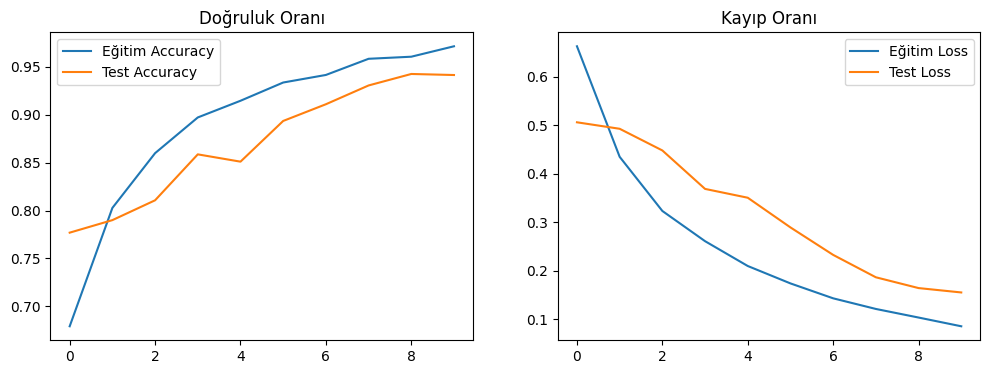

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import os


DATA_DIR = '/Users/sametyardimci/Desktop/dataset' 
IMG_SIZE = 224
BATCH_SIZE = 32

print("Veriler taranıyor ve hazırlanıyor...")


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


try:
    from sklearn.utils import class_weight
    train_classes = train_generator.classes
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_classes),
        y=train_classes
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Sınıf Ağırlıkları: {class_weights_dict}")
except:
    print("Sklearn kütüphanesi bulunamadı veya hata oluştu, ağırlıklandırma atlanıyor (Sorun değil).")
    class_weights_dict = None


base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)


model.compile(optimizer=Adam(learning_rate=0.00001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])


checkpoint = ModelCheckpoint(
    'beyin_modelim_final.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)


EPOCHS = 10 
print(f"\n🚀 EĞİTİM BAŞLIYOR... ({EPOCHS} Epoch)")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[checkpoint]
) 


print("\n✅ EĞİTİM TAMAMLANDI!")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.title('Doğruluk Oranı')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title('Kayıp Oranı')
plt.show()

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os


os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
tf.get_logger().setLevel('ERROR')


print("Yapay Zeka Yükleniyor...")
try:
   
    if os.path.exists('beyin_modelim_final.keras'):
        final_model = tf.keras.models.load_model('beyin_modelim_final.keras', compile=False)
    else:
        final_model = tf.keras.models.load_model('beyin_modelim_final.h5', compile=False)
    print("✅ MODEL HAZIR! (Standart Eşik Değeri: 0.50)")
except:
    print("❌ HATA: Model dosyası bulunamadı. Lütfen eğitimi tamamlayın.")

# --- ARAYÜZ ---
uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='1. Resim Seç',
    button_style='primary' 
)

analyze_btn = widgets.Button(
    description='2. Analiz Et',
    button_style='success', 
    icon='check'
)

out = widgets.Output()

def on_analyze_click(b):
    out.clear_output()
    
    with out:
        if not uploader.value:
            print("⚠️ Lütfen önce bir resim seçin!")
            return
            
        try:
       
            if isinstance(uploader.value, dict):
                uploaded_file = list(uploader.value.values())[0]
            else:
                uploaded_file = uploader.value[0]
                
            content = uploaded_file['content']
            image = Image.open(io.BytesIO(content)).convert('RGB')
            img_array = np.array(image)
            
         
            img_resized = cv2.resize(img_array, (224, 224))
            img_normalized = img_resized / 255.0
            img_expanded = np.expand_dims(img_normalized, axis=0)
            
      
            pred = final_model.predict(img_expanded, verbose=0)[0][0]
            
         
            THRESHOLD = 0.50 
            
            if pred > THRESHOLD:
                sonuc = "⚠️ TÜMÖR TESPİT EDİLDİ (YES)"
                guven = pred * 100
                renk = 'red'
            else:
                sonuc = "✅ TEMİZ / TÜMÖR YOK (NO)"
                guven = (1 - pred) * 100
                renk = 'green'
            
            # Sonucu Göster
            plt.figure(figsize=(6,6))
            plt.imshow(img_array)
            plt.title(f"{sonuc}\nDoğruluk: %{guven:.2f}", color=renk, fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.show()
            
        except Exception as e:
            print(f"Hata: {e}")

analyze_btn.on_click(on_analyze_click)

print("Sistem Kullanıma Hazır. Lütfen test resmini yükleyin.")
display(uploader)
display(analyze_btn)
display(out)

Yapay Zeka Yükleniyor...
✅ MODEL HAZIR! (Standart Eşik Değeri: 0.50)
Sistem Kullanıma Hazır. Lütfen test resmini yükleyin.


FileUpload(value=(), accept='image/*', button_style='primary', description='1. Resim Seç')

Button(button_style='success', description='2. Analiz Et', icon='check', style=ButtonStyle())

Output()